# Feature engineering - data preparation pipeline  | Sebislaw

## Libraries

In [1]:
from os.path  import join
import random
import itertools
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from pandas.plotting import parallel_coordinates
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

from sklearn.linear_model import LinearRegression, LassoCV, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, StratifiedKFold, RandomizedSearchCV
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
import xgboost as xgb
from xgboost import XGBClassifier
import optuna
# from tabpfn import TabPFNClassifier

## Data

In [2]:
data_path = '../../data'
pd.set_option('display.max_columns', None)

# The Basics ------------------------------------------------------------------------
# Men
MTeams = pd.read_csv(join(data_path, 'MTeams.csv'))
MSeasons = pd.read_csv(join(data_path, 'MSeasons.csv'))
MNCAATourneySeeds = pd.read_csv(join(data_path, 'MNCAATourneySeeds.csv'))
MRegularSeasonCompactResults = pd.read_csv(join(data_path, 'MRegularSeasonCompactResults.csv'))
MNCAATourneyCompactResults = pd.read_csv(join(data_path, 'MNCAATourneyCompactResults.csv'))
# Women
WTeams = pd.read_csv(join(data_path, 'WTeams.csv'))
WSeasons = pd.read_csv(join(data_path, 'WSeasons.csv'))
WNCAATourneySeeds = pd.read_csv(join(data_path, 'WNCAATourneySeeds.csv'))
WRegularSeasonCompactResults = pd.read_csv(join(data_path, 'WRegularSeasonCompactResults.csv'))
WNCAATourneyCompactResults = pd.read_csv(join(data_path, 'WNCAATourneyCompactResults.csv'))
# Other
SampleSubmissionStage1 = pd.read_csv(join(data_path, 'SampleSubmissionStage1.csv'))
SampleSubmissionStage2 = pd.read_csv(join(data_path, 'SampleSubmissionStage2.csv'))
SeedBenchmarkStage1 = pd.read_csv(join(data_path, 'SeedBenchmarkStage1.csv'))

# Team Box Scores ------------------------------------------------------------------------
# Men
MRegularSeasonDetailedResults = pd.read_csv(join(data_path, 'MRegularSeasonDetailedResults.csv'))
MNCAATourneyDetailedResults = pd.read_csv(join(data_path, 'MNCAATourneyDetailedResults.csv'))
# Women
WRegularSeasonDetailedResults = pd.read_csv(join(data_path, 'WRegularSeasonDetailedResults.csv'))
WNCAATourneyDetailedResults = pd.read_csv(join(data_path, 'WNCAATourneyDetailedResults.csv'))

# Geography ------------------------------------------------------------------------
# All
Cities = pd.read_csv(join(data_path, 'Cities.csv'))
Conferences = pd.read_csv(join(data_path, 'Conferences.csv'))
# Men
MGameCities = pd.read_csv(join(data_path, 'MGameCities.csv'))
# Women
WGameCities = pd.read_csv(join(data_path, 'WGameCities.csv'))

# Public Rankings ------------------------------------------------------------------------
# Men
MMasseyOrdinals = pd.read_csv(join(data_path, 'MMasseyOrdinals.csv')) # men only

# Supplements ------------------------------------------------------------------------
# Men
MTeamCoaches = pd.read_csv(join(data_path, 'MTeamCoaches.csv')) # men only
MTeamConferences = pd.read_csv(join(data_path, 'MTeamConferences.csv'))
MConferenceTourneyGames = pd.read_csv(join(data_path, 'MConferenceTourneyGames.csv'))
MSecondaryTourneyTeams = pd.read_csv(join(data_path, 'MSecondaryTourneyTeams.csv'))
MSecondaryTourneyCompactResults = pd.read_csv(join(data_path, 'MSecondaryTourneyCompactResults.csv'))
MTeamSpellings = pd.read_csv(join(data_path, "MTeamSpellings.csv"), encoding='cp1252')
MNCAATourneySlots = pd.read_csv(join(data_path, 'MNCAATourneySlots.csv'))
MNCAATourneySeedRoundSlots = pd.read_csv(join(data_path, 'MNCAATourneySeedRoundSlots.csv')) # men only
# Women
WTeamConferences = pd.read_csv(join(data_path, 'WTeamConferences.csv'))
WConferenceTourneyGames = pd.read_csv(join(data_path, 'WConferenceTourneyGames.csv'))
WSecondaryTourneyTeams = pd.read_csv(join(data_path, 'WSecondaryTourneyTeams.csv'))
WSecondaryTourneyCompactResults = pd.read_csv(join(data_path, 'WSecondaryTourneyCompactResults.csv'))
WTeamSpellings = pd.read_csv(join(data_path, 'WTeamSpellings.csv'), encoding='cp1252')
WNCAATourneySlots = pd.read_csv(join(data_path, 'WNCAATourneySlots.csv'))

## Data preparation pipeline

In [3]:
def prepare_data(df):
        
    """
    This function duplicates and flips a game record.
    Now two records with the same data are present, 
    but viewed from perspectives of two different teams.
    """
    
    df = df[[
         'Season', 'DayNum', 'NumOT',
         'WTeamID',  'WScore', 'WLoc',
         'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF',
         'LTeamID', 'LScore',
         'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'
    ]]
    dfswap = df[[
         'Season', 'DayNum', 'NumOT',
         'LTeamID', 'LScore', 'WLoc',
         'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF',
         'WTeamID',  'WScore',
         'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF',
    ]].copy()
    
    dfswap.loc[df['WLoc'] == 'H', 'WLoc'] = 'A'
    dfswap.loc[df['WLoc'] == 'A', 'WLoc'] = 'H'
        
    df = df.rename(columns={'WLoc': 'location'})
    dfswap = dfswap.rename(columns={'WLoc': 'location'})
        
    df.columns = [x.replace('W','T1_').replace('L','T2_') for x in list(df.columns)]
    dfswap.columns = [x.replace('L','T1_').replace('W','T2_') for x in list(dfswap.columns)]
    
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output.loc[output.location=='N','location'] = '0'
    output.loc[output.location=='H','location'] = '1'
    output.loc[output.location=='A','location'] = '-1'
    output.location = output.location.astype(int)
        
    output['PointDiff'] = output['T1_Score'] - output['T2_Score']
    
    return output

def get_data(regular_results, tourney_results, seeds, prepared=False, location_multiplier=[1, 1], win_ratio_days_back=14):

    """
    This function uses the prepare_data function in order to create
    a data frame with season statistics for each team.
    These statistics are added to records with games played in
    tournament to make data 'x' used in model to predict the game 
    result 'y'. The output is a data frame that contains data 'x'
    and also label 'y' can be easily calculated based on score difference in matches.
    """

    if prepared:
        regular_data = regular_results.copy()
        tourney_data = tourney_results.copy()
    else:
        # make data frames with extra rows to represent the perspective of losing team
        regular_data = prepare_data(regular_results)
        tourney_data = prepare_data(tourney_results)

    # ----------------------------------- Add reward/penalty for playing in home or away
    if location_multiplier[0] == 1 and location_multiplier[1] == 1:
        # data frame with mean game statistics for a given team in a given season
        season_statistics  = regular_data.groupby(["Season", 'T1_TeamID'])[
            [
                'T1_Score', 'T1_FGM','T1_FGA','T1_FGM3','T1_FGA3','T1_FTM','T1_FTA',
                'T1_OR','T1_DR','T1_Ast','T1_TO','T1_Stl','T1_Blk','T1_PF',
                'T2_Score', 'T2_FGM','T2_FGA','T2_FGM3','T2_FGA3','T2_FTM','T2_FTA',
                'T2_OR','T2_DR','T2_Ast','T2_TO','T2_Stl','T2_Blk','T2_PF',
                'PointDiff'
            ]
        ].agg('mean').reset_index()
    else:
        # Define which columns to adjust (you can add or remove columns as needed)
        T1_cols = ['T1_Score','T1_FGM','T1_FGA','T1_FGM3','T1_FGA3','T1_FTM','T1_FTA','T1_OR','T1_DR','T1_Ast','T1_TO','T1_Stl','T1_Blk','T1_PF']
        T2_cols = ['T2_Score','T2_FGM','T2_FGA','T2_FGM3','T2_FGA3','T2_FTM','T2_FTA','T2_OR','T2_DR','T2_Ast','T2_TO','T2_Stl','T2_Blk','T2_PF']
    
        # Convert the relevant columns to float before applying the adjustment function.
        cols_to_float = T1_cols + T2_cols
        regular_data[cols_to_float] = regular_data[cols_to_float].astype(float)
        
        def adjust_stats(row):
            # Determine multipliers based on location
            if row['location'] == 1:
                factor_T1 = location_multiplier[0]  # penalize Team1 stats (home)
                factor_T2 = location_multiplier[1]  # boost Team2 stats
            elif row['location'] == -1:
                factor_T1 = location_multiplier[1]  # boost Team1 stats (away)
                factor_T2 = location_multiplier[0]  # penalize Team2 stats
            else:
                factor_T1 = 1.0
                factor_T2 = 1.0
        
            # Adjust Team1 stats
            for col in T1_cols:
                if col in row and pd.notnull(row[col]):
                    row[col] = row[col] * factor_T1
        
            # Adjust Team2 stats
            for col in T2_cols:
                if col in row and pd.notnull(row[col]):
                    row[col] = row[col] * factor_T2
        
            # Recalculate derived statistics (if needed)
            if 'T1_Score' in row and 'T2_Score' in row:
                row['PointDiff'] = row['T1_Score'] - row['T2_Score']
            return row
        
        # Apply the adjustment function row-wise.
        regular_data_adjusted = regular_data.apply(adjust_stats, axis=1)
        
        # Now group by Season and T1_TeamID to compute season averages for the adjusted statistics.
        stats_columns = T1_cols[1:] + T2_cols[1:] + ['PointDiff']  # Exclude T1_TeamID from stats if present.
        season_statistics = regular_data_adjusted.groupby(["Season", 'T1_TeamID'])[stats_columns].agg('mean').reset_index()
    # -----------------------------------
    
    # mean statistics for team and team's opponent's
    season_statistics_T1 = season_statistics.copy()
    season_statistics_T2 = season_statistics.copy()
    
    season_statistics_T1.columns = ["T1_" + x.replace("T1_","").replace("T2_","opponent_") for x in list(season_statistics_T1.columns)]
    season_statistics_T2.columns = ["T2_" + x.replace("T1_","").replace("T2_","opponent_") for x in list(season_statistics_T2.columns)]
    season_statistics_T1.columns.values[0] = "Season"
    season_statistics_T2.columns.values[0] = "Season"
    season_statistics_T1 = season_statistics_T1.rename(columns={'T1_Score': 'T1_Score_mean'})
    season_statistics_T2 = season_statistics_T2.rename(columns={'T2_Score': 'T2_Score_mean'})
    
    # data frame containing game's result
    tourney_data = tourney_data[['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID' ,'T2_Score', 'location']]
    tourney_data = pd.merge(tourney_data, season_statistics_T1, on = ['Season', 'T1_TeamID'], how = 'left')
    tourney_data = pd.merge(tourney_data, season_statistics_T2, on = ['Season', 'T2_TeamID'], how = 'left')

    calculate_win_ratio_days_back = 132 - win_ratio_days_back
    
    # data frame with win fraction from last x days for a given team in a given season
    last14days_stats_T1 = regular_data.loc[regular_data.DayNum>calculate_win_ratio_days_back].reset_index(drop=True)
    last14days_stats_T1['win'] = np.where(last14days_stats_T1['PointDiff']>0,1,0)
    last14days_stats_T1 = last14days_stats_T1.groupby(['Season','T1_TeamID'])['win'].mean().reset_index(name='T1_win_ratio_14d')
    
    last14days_stats_T2 = regular_data.loc[regular_data.DayNum>calculate_win_ratio_days_back].reset_index(drop=True)
    last14days_stats_T2['win'] = np.where(last14days_stats_T2['PointDiff']<0,1,0)
    last14days_stats_T2 = last14days_stats_T2.groupby(['Season','T2_TeamID'])['win'].mean().reset_index(name='T2_win_ratio_14d')
    
    # add to tourney_data column with win fraction for winning and losing team
    tourney_data = pd.merge(tourney_data, last14days_stats_T1, on = ['Season', 'T1_TeamID'], how = 'left')
    tourney_data = pd.merge(tourney_data, last14days_stats_T2, on = ['Season', 'T2_TeamID'], how = 'left')
    
    # get seeds with no regional division
    seeds['seed'] = seeds['Seed'].apply(lambda x: int(x[1:3]))
    
    # give each team a raw seed
    seeds_T1 = seeds[['Season','TeamID','seed']].copy()
    seeds_T2 = seeds[['Season','TeamID','seed']].copy()
    seeds_T1.columns = ['Season','T1_TeamID','T1_seed']
    seeds_T2.columns = ['Season','T2_TeamID','T2_seed']
    
    # add seeds to turney data for team 1 and team 2
    tourney_data = pd.merge(tourney_data, seeds_T1, on = ['Season', 'T1_TeamID'], how = 'left')
    tourney_data = pd.merge(tourney_data, seeds_T2, on = ['Season', 'T2_TeamID'], how = 'left')
    
    # add a seed difference column
    tourney_data["Seed_diff"] = tourney_data["T1_seed"] - tourney_data["T2_seed"]

    return tourney_data

def get_df(seeds,
            season_games, season_range, days_back,
            tourney_games, tourney_range, 
            location_multiplier=[1, 1],
           win_ratio_days_back=14):

    """
    This function uses get_data function to get a data
    frame which is then used to make 'x' and 'y' data
    used in models.
    """
    
    # Get from regular season games from specified season range and days back
    # The results of those games will be used as team statictics (additional team information for tourney games)
    regular_results = season_games[season_games['Season'].isin(season_range)]
    regular_results = regular_results[regular_results['DayNum'] > 134 - days_back]
    
    # Get tourney games from a specified season
    # The results of those games will be used as labels
    tourney_results = tourney_games[tourney_games['Season'].isin(tourney_range)]
    
    # Get final data frame
    df = get_data(regular_results, tourney_results, seeds, location_multiplier=[1, 1], win_ratio_days_back=win_ratio_days_back)
    
    return df

def get_final_df(seeds,
                   season_games, season_range, days_back,
                   tourney_games, tourney_range, 
                   SampleSubmissionStage1,
                  location_multiplier=[1, 1],
                win_ratio_days_back=14):

    """
    This function works the same as function get_x_y,
    but also creates (at the moment it's the same as get_x_y)
    aditional data points mostly with NaN values that matches
    the submission format (parsed team matchups with the sample submission file).
    """

    # Get from regular season games from specified season range and days back
    # The results of those games will be used as team statictics (additional team information for tourney games)
    regular_results = season_games[season_games['Season'].isin(season_range)]
    regular_results = regular_results[regular_results['DayNum'] > 134 - days_back]

    # Get tourney games from a specified season
    # The results of those games will be used as labels
    tourney_results = tourney_games[tourney_games['Season'].isin(tourney_range)]
    
    # Assume sample_submission is a DataFrame with an "ID" column like "2023_1101_1102"
    # and tourney_results is a DataFrame with columns including: Season, WTeamID, LTeamID, DayNum, WScore, LScore, WLoc, etc.
    # Filter rows where the ID starts with the specified season (followed by an underscore)
    final_season = tourney_range[0]
    sample_submission_copy = SampleSubmissionStage1.copy()
    sample_submission = sample_submission_copy[sample_submission_copy['ID'].str.startswith(f"{final_season}_")]
    sample_submission = sample_submission.drop(columns=['Pred'])
    
    sample_submission[['Season', 'Team1', 'Team2']] = sample_submission['ID'].str.split('_', expand=True)
    sample_submission['Season'] = sample_submission['Season'].astype(float)
    sample_submission['Team1'] = sample_submission['Team1'].astype(float)
    sample_submission['Team2'] = sample_submission['Team2'].astype(float)
    
    regular_data_final = prepare_data(regular_results)
    tourney_data_final  = prepare_data(tourney_results)
    
    tourney_data =  get_data(regular_data_final, tourney_data_final,
                             seeds, prepared=True,
                          win_ratio_days_back=win_ratio_days_back)
    tourney_data = pd.merge(
        sample_submission,
        tourney_data,
        left_on=['Season', 'Team1', 'Team2'],
        right_on=['Season', 'T1_TeamID', 'T2_TeamID'],
        how='left'
    )
    tourney_data['T1_TeamID'] = tourney_data['Team1']
    tourney_data['T2_TeamID'] = tourney_data['Team2']
    tourney_data = tourney_data.drop(['ID', 'Team1', 'Team2'], axis=1)
    
    return tourney_data

def correct_predictions_based_on_seed(x, y, maximum_favoured_seed = 4, number_of_added_columns=1):
    """
    Sets the winnning chance to 1 or 0 based on the seed difference.
    """
    for i in range(len(x)):
        if x[i][-1-number_of_added_columns] <= (-16 + maximum_favoured_seed * 2 - 1):
            y[i] = 1
        elif x[i][-1-number_of_added_columns] >= (16 - maximum_favoured_seed * 2 + 1):
            y[i] = 0
    return y

def clear_na_from_x_y(x, y):
    """
    The data frame for final season is in format matching the submission file.
    This function clears NaNs from data.
    """
    # Create masks for training data:
    mask_train = ~np.isnan(x).any(axis=1) & ~np.isnan(y)
    x_clean = x[mask_train]
    y_clean = y[mask_train]
    return x_clean, y_clean

def x_y_from_data_frame(df):
    # Prepare data and labels
    x = df[list(df.columns[7:])].values
    y = np.where(
        df[['T1_Score', 'T2_Score']].isnull().any(axis=1),
        np.nan,
        np.where(df['T1_Score'] - df['T2_Score'] > 0, 1, 0)
    )
    return x, y

def x_y_from_data_frame_score(df):
    # Prepare data and labels
    x = df[list(df.columns[7:])].values
    y = np.where(
        df[['T1_Score', 'T2_Score']].isnull().any(axis=1),
        np.nan,
        df['T1_Score'] - df['T2_Score']
    )
    return x, y

def get_all_core_data(
    regular_results, tourney_results, seeds, SampleSubmissionStage1,
    final_season = 2024, # the season we want to predict, so for out submission it will be 2025
    start_season = 2005, # from which ponit should we begin creating data
    season_years_list  = [[i-1, i] for i in range(2005, 2024+1)], # at which seasons to look at when calculating team's stats
    days_back = 15, # how many days back from the start of tourney to calculate team's stats per season
    maximum_favoured_seed = 4, # Set the predicted probability of winning to 1 for seeds <= maximum_favoured_seed and to 0 for >= 16-maximum_favoured_seed
    location_multiplier=[0.95, 1.05], # home penalty, away bonus 
    include_men = True, # include M... data sets when preparing x and y
    include_women = True, # include W... data sets when preparing x and y
    win_ratio_days_back = 14):

    """
    The idea of this function is to easily get data needed to train and test the model later on, with minimal code
    to not clutter the netebook.
    
    This function outputs df, x, y, df_final, x_final_season, y_final_season.
    
    df is a data frame with first 6 columns from tourney games and other calculated from other data frames.
    
    Adding a column to df and executing x_y_from_data_frame(df) function will yield x with added data.
    
    Note that df_final has the same structure as df, but also with rows with NaNs. The rows with missing information are there
    to match the sumbission file format. The separation of those data frames is to ensure that information from last season doesn't
    leak into training data due to poorly written code.
    
    x has df columns from location onwardsthe columns before that are from tourney games and are used to calculate y (based on points).
    
    y has label 0 or 1 (lose or win) and nan if the correspoinding data in x was nan.
    
    There is also x_final_season and y_final_season aquired from df_final, which are the same as x and y, but like df_final, they have NaNs. 
    """

    # This ensures that we simulate the scenario in competition
    tourney_results_final = tourney_results[tourney_results['Season'] == final_season]
    tourney_results = tourney_results[tourney_results['Season'] < final_season]
    regular_results = regular_results[regular_results['Season'] != 2020] # This year had no tournament data
    tourney_years_list = [[i] for i in range(start_season, final_season+1)]
    
    # Arrays to store data
    data = []
    x = []
    y = []
    data_final = []
    x_final_season = []
    y_final_season = []
    for season_years, tourney_years in zip(season_years_list, tourney_years_list):
        if tourney_years[0] != 2020: # This year had no tournament data
            
            # Create data separately for the final tournament
            if tourney_years[0] == final_season:
                data_tmp_final = get_final_df(
                    seeds,
                    regular_results, season_years, days_back,
                    tourney_results_final, tourney_years, 
                    SampleSubmissionStage1,
                    location_multiplier=location_multiplier,
                    win_ratio_days_back=win_ratio_days_back
                )
                # Array to store data
                data_final.append(data_tmp_final)
                
            else:
                # Create data separately for the rest of games besides for the final tournament
                data_tmp = get_df(
                    seeds,
                    regular_results, season_years, days_back,
                    tourney_results, tourney_years,
                    location_multiplier=location_multiplier,
                    win_ratio_days_back=win_ratio_days_back
                )
                # Array to store data
                data.append(data_tmp)
    
    
    
    # complete data from which x and y can be calculated + more for all tournament games besides for the final tournament
    df = pd.concat(data, ignore_index=True)
    
    # the same as df, but only for the final tournament
    df_final = pd.concat(data_final, ignore_index=True)
    
    return df, df_final

In [4]:
def x_y_from_data_frame_differences(df):
    # Extract the score difference for y (target variable)
    y = np.where(
        df[['T1_Score', 'T2_Score']].isnull().any(axis=1),
        np.nan,
        np.where(df['T1_Score'] - df['T2_Score'] > 0, 1, 0)
    )
    
    # Identify pairs of columns for which to calculate differences
    # Exclude non-paired columns and the score columns which were already used for y
    paired_columns = []
    difference_names = []
    
    # Define column prefixes to look for
    t1_prefixes = ['T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 
                  'T1_OR', 'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF',
                  'T1_opponent_Score', 'T1_opponent_FGM', 'T1_opponent_FGA', 
                  'T1_opponent_FGM3', 'T1_opponent_FGA3', 'T1_opponent_FTM', 
                  'T1_opponent_FTA', 'T1_opponent_OR', 'T1_opponent_DR', 
                  'T1_opponent_Ast', 'T1_opponent_TO', 'T1_opponent_Stl', 
                  'T1_opponent_Blk', 'T1_opponent_PF', 'T1_PointDiff',
                  'T1_Score_mean', 'T1_win_ratio_14d', 'T1_seed']
    
    # Create mapping from T1 to T2 prefixes
    t2_equiv = {col: col.replace('T1_', 'T2_') for col in t1_prefixes}
    
    # Check if columns exist in dataframe and create pairs
    for t1_col, t2_col in t2_equiv.items():
        if t1_col in df.columns and t2_col in df.columns:
            paired_columns.append((t1_col, t2_col))
            # Create more meaningful names for difference columns
            diff_name = t1_col.replace('T1_', '') + '_difference'
            difference_names.append(diff_name)
    
    # Add non-paired columns that should be included directly
    direct_columns = ['Season', 'DayNum', 'location', 'TeamELO', 'CoachELO', 'Seed_diff']
    existing_direct_cols = [col for col in direct_columns if col in df.columns]
    
    # Calculate differences for paired columns
    differences = pd.DataFrame()
    for (t1_col, t2_col), diff_name in zip(paired_columns, difference_names):
        differences[diff_name] = df[t1_col] - df[t2_col]
    
    # Add the direct columns (non-difference features)
    for col in existing_direct_cols:
        differences[col] = df[col]
    
    # Convert to numpy array for the final x
    x = differences.values
    
    return x, y

## How to get df_train and df_test
df_train is used to get x_train and y_train\
df_test is used to get x_test and y_test (for season we want to predict)\
First 7 columns in df_... are used for calculating y\

In [16]:
# PARAMETERS TO CHANGE
final_season = 2024 # the season we want to predict, so for out submission it will be 2025
start_season = final_season-2 # from which ponit should we begin creating data
season_years_list  = [[i] for i in range(start_season, final_season+1)] # at which seasons to look at when calculating team's stats
days_back = 14 # how many days back from the start of tourney to calculate team's stats per season
maximum_favoured_seed = 4 # Set the predicted probability of winning to 1 for seeds <= maximum_favoured_seed and to 0 for >= 16-maximum_favoured_seed
location_multiplier = [0.65, 1.35] # home penalty, away bonus ex.
win_ratio_days_back = 14
include_men = True # include M... data sets when preparing x and y
include_women = False # include W... data sets when preparing x and y

In [17]:
# READ DATA
regular_results = pd.concat([
    MRegularSeasonDetailedResults.copy() if include_men else None,
    WRegularSeasonDetailedResults.copy() if include_women else None
], ignore_index=True)
tourney_results = pd.concat([
    MNCAATourneyDetailedResults.copy() if include_men else None,
    WNCAATourneyDetailedResults.copy() if include_women else None
], ignore_index=True)
seeds = pd.concat([
    MNCAATourneySeeds.copy() if include_men else None,
    WNCAATourneySeeds.copy() if include_women else None
], ignore_index=True)
number_of_added_columns = 0 # If you add any columns AFTER obtaining data from get_all_core_data change this counter

In [18]:
# GET ALL DATA NEEDED TO USE THE MODELS
df_train, df_test = get_all_core_data(
    regular_results, tourney_results, seeds, SampleSubmissionStage1, final_season = final_season,
    start_season = start_season, season_years_list  = season_years_list, days_back = days_back,
    maximum_favoured_seed = maximum_favoured_seed, location_multiplier=location_multiplier,
    include_men = include_men, include_women = include_women, win_ratio_days_back = win_ratio_days_back)

## How to add more columns to data frame

In [19]:
# ADD TEAM AND COACH ELO AND REPLACE NAN WITH MEAN

if include_men:
    elo = pd.read_csv(join(data_path, 'elo.csv'))
    elo['CoachELO'] = elo['CoachELO'].fillna(elo['CoachELO'].mean())

    def add_elo_column(df):
        df = df.copy()
        df = pd.merge(
                df,
                elo[['Season', 'DayNum', 'TeamID', 'TeamELO', 'CoachELO']],
                left_on=['Season', 'DayNum', 'T1_TeamID'],
                right_on=['Season', 'DayNum', 'TeamID'],
                how='left'
            )
        df = df.drop(['TeamID'], axis=1)
        return df

    df_train = add_elo_column(df_train)
    df_test = add_elo_column(df_test)

    number_of_added_columns = 2

## How to get x and y

In [20]:
# Get x, y train and test fromd data frames
x_train, y_train = x_y_from_data_frame(df_train)
x_test, y_test = x_y_from_data_frame(df_test)

# Get data frames with columns present in x_train and x_test
df_train_x = df_train.iloc[:, 6:]
df_test_x = df_test.iloc[:, 6:]

# Clear NaN if it's present
x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())

# MOJE

In [32]:
from sklearn.metrics import log_loss, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [21]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [33]:
# List of models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
}


In [34]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(x_train_scaled, y_train)
    
    # Predict probabilities
    y_pred_proba = model.predict_proba(x_test_scaled)[:, 1]
    
    # Evaluate Metrics
    brier = brier_score_loss(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, (y_pred_proba > 0.5).astype(int))  # Convert probabilities to binary predictions
    
    # Store results
    results[name] = {"Brier Score": brier, "Log Loss": logloss, "Accuracy": accuracy}
    print(f"{name} -> Brier Score: {brier:.5f}, Log Loss: {logloss:.5f}, Accuracy: {accuracy:.5f}")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T.sort_values("Brier Score")
print("\nModel Performance Comparison:")
print(results_df)

Training Logistic Regression...
Logistic Regression -> Brier Score: 0.26449, Log Loss: 0.77622, Accuracy: 0.58209
Training Random Forest...
Random Forest -> Brier Score: 0.21073, Log Loss: 0.61101, Accuracy: 0.68657
Training Gradient Boosting...
Gradient Boosting -> Brier Score: 0.21129, Log Loss: 0.64022, Accuracy: 0.73134
Training XGBoost...


c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", li

XGBoost -> Brier Score: 0.24780, Log Loss: 0.72556, Accuracy: 0.62687
Training LightGBM...
[LightGBM] [Info] Number of positive: 139, number of negative: 139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3054
[LightGBM] [Info] Number of data points in the train set: 278, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## RF - tuning

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize RandomForest model
rf_model = RandomForestClassifier(random_state=42)

# Randomized Search
rf_random = RandomizedSearchCV(estimator=rf_model, param_distributions=rf_param_grid, 
                               n_iter=30, cv=5, scoring='neg_brier_score', 
                               verbose=2, random_state=42, n_jobs=-1)

# Fit the model
rf_random.fit(x_train_scaled, y_train)

# Best parameters
print("Best RF Parameters:", rf_random.best_params_)

# Use best model
best_rf = rf_random.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}


## Gradient boosting

In [57]:
from sklearn.ensemble import GradientBoostingClassifier


# Define hyperparameter grid
gb_param_grid = {
    'n_estimators': [10, 15, 20, 25, 30, 100],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.85, 0.9, 0.95, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GradientBoosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Randomized Search
gb_random = RandomizedSearchCV(estimator=gb_model, param_distributions=gb_param_grid, 
                               n_iter=30, cv=3, scoring='neg_brier_score', 
                               verbose=2, random_state=42, n_jobs=-1)

# Fit the model
gb_random.fit(x_train_scaled, y_train)

# Best parameters
print("Best GB Parameters:", gb_random.best_params_)

# Use best model
best_gb = gb_random.best_estimator_


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best GB Parameters: {'subsample': 0.85, 'n_estimators': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 8, 'learning_rate': 0.05}


In [60]:
import optuna
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import make_scorer, brier_score_loss
from sklearn.model_selection import cross_val_score

# Define Objective Function for Bayesian Optimization
def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 10, 150)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    subsample = trial.suggest_float("subsample", 0.25, 1.0)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 4)
    
    # Define the model
    gb_model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    # Evaluate using Cross-Validation (3 folds)
    score = cross_val_score(gb_model, x_train_scaled, y_train, 
                            cv=3, scoring=make_scorer(brier_score_loss, greater_is_better=False)).mean()
    
    return score  # Optuna minimizes this value (-Brier Score)

# Run Bayesian Optimization
study = optuna.create_study(direction="maximize")  # Maximize negative Brier Score (equivalent to minimizing Brier Score)
study.optimize(objective, n_trials=30, n_jobs=-1)

# Best parameters
best_params = study.best_params
print("Best GB Parameters:", best_params)

# Train Best Model on Full Training Data
best_gb = GradientBoostingClassifier(**best_params, random_state=42)
best_gb.fit(x_train_scaled, y_train)


[I 2025-03-19 22:07:02,967] A new study created in memory with name: no-name-e33fbec7-21bf-437e-8340-d1e84e00b3b4
[I 2025-03-19 22:07:04,768] Trial 0 finished with value: -0.4029141343306841 and parameters: {'n_estimators': 33, 'learning_rate': 0.020217498396520518, 'max_depth': 3, 'subsample': 0.322607775164987, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 0 with value: -0.4029141343306841.
[I 2025-03-19 22:07:05,632] Trial 11 finished with value: -0.4349774037712327 and parameters: {'n_estimators': 18, 'learning_rate': 0.0516998428762491, 'max_depth': 10, 'subsample': 0.8547049811079439, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: -0.4029141343306841.
[I 2025-03-19 22:07:05,717] Trial 8 finished with value: -0.4063035686457846 and parameters: {'n_estimators': 34, 'learning_rate': 0.10595196540730964, 'max_depth': 4, 'subsample': 0.7744309473357904, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 0 with value: -0.402914134

Best GB Parameters: {'n_estimators': 37, 'learning_rate': 0.011230290324848204, 'max_depth': 7, 'subsample': 0.2793036810808751, 'min_samples_split': 4, 'min_samples_leaf': 3}


GradientBoostingClassifier(learning_rate=0.011230290324848204, max_depth=7,
                           min_samples_leaf=3, min_samples_split=4,
                           n_estimators=37, random_state=42,
                           subsample=0.2793036810808751)

## DEAP

In [62]:
pip install deap


Note: you may need to restart the kernel to use updated packages.


In [65]:
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import cross_val_score

# Define objective function for GA with fixed parameter ranges
def evaluate(params):
    n_estimators, learning_rate, max_depth, min_samples_split, min_samples_leaf, subsample = params
    
    # Ensure valid values for sklearn parameters
    n_estimators = max(10, int(n_estimators))  # Ensure at least 10 trees
    learning_rate = max(0.01, learning_rate)  # Minimum learning rate 0.01
    max_depth = max(3, int(max_depth))  # Ensure minimum depth of 3
    min_samples_split = max(2, int(min_samples_split))  # Ensure at least 2
    min_samples_leaf = max(1, int(min_samples_leaf))  # Ensure at least 1
    subsample = max(0.5, min(1.0, subsample))  # Keep subsample in [0.5, 1.0]

    # Initialize GB model
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=42
    )
    
    # Cross-validation Brier Score
    score = cross_val_score(model, x_train_scaled, y_train, 
                            cv=3, scoring="neg_brier_score").mean()
    return (-score, )  # Minimize Brier Score


# Genetic Algorithm Setup
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))  # Minimize Brier Score
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_n_estimators", np.random.randint, 10, 100)
toolbox.register("attr_learning_rate", np.random.uniform, 0.01, 0.1)
toolbox.register("attr_max_depth", np.random.randint, 3, 10)
toolbox.register("attr_min_samples_split", np.random.randint, 2, 10)
toolbox.register("attr_min_samples_leaf", np.random.randint, 2, 5)
toolbox.register("attr_subsample", np.random.uniform, 0.7, 1.0)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_n_estimators, toolbox.attr_learning_rate, toolbox.attr_max_depth,
                  toolbox.attr_min_samples_split, toolbox.attr_min_samples_leaf, toolbox.attr_subsample), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# Run Genetic Algorithm
pop = toolbox.population(n=10)
algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=10, verbose=True)

# Get Best Individual
best_individual = tools.selBest(pop, k=1)[0]
best_params_ga = {
    "n_estimators": int(best_individual[0]),
    "learning_rate": best_individual[1],
    "max_depth": int(best_individual[2]),
    "min_samples_split": int(best_individual[3]),
    "min_samples_leaf": int(best_individual[4]),
    "subsample": best_individual[5],
}

print("Best GB Parameters (Genetic Algorithm):", best_params_ga)

# Train Best Model
best_gb_ga = GradientBoostingClassifier(**best_params_ga, random_state=42)
best_gb_ga.fit(x_train_scaled, y_train)


c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals
0  	10    
1  	3     
2  	3     
3  	8     
4  	10    
5  	1     
6  	6     
7  	8     
8  	7     
9  	6     
10 	5     
Best GB Parameters (Genetic Algorithm): {'n_estimators': 19, 'learning_rate': 0.0633833579462286, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 3, 'subsample': 0.7421386184463288}


GradientBoostingClassifier(learning_rate=0.0633833579462286, max_depth=4,
                           min_samples_leaf=3, min_samples_split=4,
                           n_estimators=19, random_state=42,
                           subsample=0.7421386184463288)

# RF - penalize outlier - 3 levels - improved

In [105]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

# Define the custom penalized Brier score with three zones
def penalized_brier_score(y_true, y_pred_proba, 
                           error_threshold_low, error_threshold_high, 
                           penalty_factor_medium, penalty_factor_high):
    """
    Computes a custom Brier score with three zones:
      - Zone 1 (Low): For errors <= error_threshold_low, no extra penalty.
      - Zone 2 (Medium): For errors between error_threshold_low and error_threshold_high, apply penalty_factor_medium.
      - Zone 3 (High): For errors > error_threshold_high, apply penalty_factor_high.
    """
    errors = np.abs(y_true - y_pred_proba)
    base_brier = (y_true - y_pred_proba) ** 2
    # Apply different penalty factors for the three zones
    penalty = np.where(errors <= error_threshold_low, 0.8,
                       np.where(errors <= error_threshold_high, penalty_factor_medium, penalty_factor_high))
    return np.mean(penalty * base_brier)

# Define the Bayesian Optimization objective function
def objective(trial):
    # Random Forest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # Hyperparameters for the penalization thresholds and factors
    error_threshold_low = 0.3
    error_threshold_high = 0.7
    penalty_factor_medium = 3
    penalty_factor_high = 10
    
    # Initialize the Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    # Get cross-validated probability predictions
    y_pred_proba = cross_val_predict(rf_model, x_train_scaled, y_train, cv=3, method="predict_proba")[:, 1]
    
    # Compute the penalized Brier score
    score = penalized_brier_score(
        y_train, y_pred_proba, 
        error_threshold_low, error_threshold_high, 
        penalty_factor_medium, penalty_factor_high
    )
    
    # Return negative score (so that Optuna maximizes it, equivalent to minimizing the true score)
    return -score

# Run Bayesian Optimization
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective, n_trials=30, n_jobs=-1)

# Retrieve best hyperparameters
best_rf_params = study_rf.best_params
print("Best Random Forest Parameters:", best_rf_params)

# Train the final best Random Forest model
best_rf = RandomForestClassifier(
    n_estimators=best_rf_params["n_estimators"],
    max_depth=best_rf_params["max_depth"],
    min_samples_split=best_rf_params["min_samples_split"],
    min_samples_leaf=best_rf_params["min_samples_leaf"],
    max_features=best_rf_params["max_features"],
    random_state=42,
    n_jobs=-1
)
best_rf.fit(x_train_scaled, y_train)

# Evaluate on the test set using the custom penalized Brier score
# y_pred_proba_rf = best_rf.predict_proba(x_test_scaled)[:, 1]
# brier_rf = penalized_brier_score(
#     y_test, y_pred_proba_rf, 
#     # best_rf_params["error_threshold_low"], 
#     # best_rf_params["error_threshold_high"],
#     # best_rf_params["penalty_factor_medium"],
#     # best_rf_params["penalty_factor_high"]
# )

print(f"🔥 Optimized Random Forest (with multi-threshold penalized loss) -> Brier Score: {brier_rf:.5f}")


[I 2025-03-19 23:02:20,083] A new study created in memory with name: no-name-ed98f306-bb70-466f-bdea-7203037e208a
[I 2025-03-19 23:02:32,466] Trial 15 finished with value: -0.7892610636701287 and parameters: {'n_estimators': 72, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 15 with value: -0.7892610636701287.
[I 2025-03-19 23:02:32,737] Trial 6 finished with value: -0.7101012838867669 and parameters: {'n_estimators': 72, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 6 with value: -0.7101012838867669.
[I 2025-03-19 23:02:33,300] Trial 3 finished with value: -0.7728625197902975 and parameters: {'n_estimators': 108, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 6 with value: -0.7101012838867669.
[I 2025-03-19 23:02:34,655] Trial 12 finished with value: -0.9175402146886018 and parameters: {'n_estimators': 182, 'max_depth'

Best Random Forest Parameters: {'n_estimators': 66, 'max_depth': 3, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
🔥 Optimized Random Forest (with multi-threshold penalized loss) -> Brier Score: 0.48557


# RF - penalize outliers - 3 levels

In [99]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

# Define a custom penalized Brier score function with multiple thresholds
def penalized_brier_score(y_true, y_pred_proba, 
                           error_threshold_low, error_threshold_high, 
                           penalty_factor_medium, penalty_factor_high):
    """
    Computes a Brier score with three penalty zones:
    - If abs(error) <= error_threshold_low: no extra penalty.
    - If error_threshold_low < abs(error) <= error_threshold_high: moderate penalty.
    - If abs(error) > error_threshold_high: high penalty.
    """
    errors = np.abs(y_true - y_pred_proba)
    base_brier = (y_true - y_pred_proba) ** 2
    # Define penalty factor based on error zones:
    penalty = np.where(errors <= error_threshold_low, 1.0,
                       np.where(errors <= error_threshold_high, penalty_factor_medium, penalty_factor_high))
    return np.mean(penalty * base_brier)

# Define the Bayesian Optimization objective function
def objective(trial):
    # Random Forest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # New hyperparameters for the penalization thresholds and factors
    error_threshold_low = trial.suggest_float("error_threshold_low", 0.2, 0.4)
    error_threshold_high = trial.suggest_float("error_threshold_high", 0.5, 0.7)
    penalty_factor_medium = trial.suggest_float("penalty_factor_medium", 2, 10)
    penalty_factor_high = trial.suggest_float("penalty_factor_high", 10, 20)
    
    # Initialize the Random Forest model with these hyperparameters.
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    # Get cross-validated probability predictions.
    y_pred_proba = cross_val_predict(rf_model, x_train_scaled, y_train, cv=3, method="predict_proba")[:, 1]
    
    # Calculate the custom penalized Brier score.
    score = penalized_brier_score(y_train, y_pred_proba, 
                                  error_threshold_low, error_threshold_high, 
                                  penalty_factor_medium, penalty_factor_high)
    
    # Return the negative score (since Optuna maximizes the objective)
    return -score

# Run Bayesian Optimization
study_rf = optuna.create_study(direction="maximize")  # Maximize negative penalized Brier Score
study_rf.optimize(objective, n_trials=30, n_jobs=-1)

# Get best parameters
best_rf_params = study_rf.best_params
print("Best Random Forest Parameters:", best_rf_params)

# Train the final best Random Forest model using the best parameters
best_rf = RandomForestClassifier(
    n_estimators=best_rf_params["n_estimators"],
    max_depth=best_rf_params["max_depth"],
    min_samples_split=best_rf_params["min_samples_split"],
    min_samples_leaf=best_rf_params["min_samples_leaf"],
    max_features=best_rf_params["max_features"],
    random_state=42,
    n_jobs=-1
)
best_rf.fit(x_train_scaled, y_train)

# Evaluate on the test set using the custom penalized Brier score
y_pred_proba_rf = best_rf.predict_proba(x_test_scaled)[:, 1]
brier_rf = penalized_brier_score(
    y_test, y_pred_proba_rf, 
    best_rf_params["error_threshold_low"], 
    best_rf_params["error_threshold_high"],
    best_rf_params["penalty_factor_medium"],
    best_rf_params["penalty_factor_high"]
)

print(f"🔥 Optimized Random Forest (with multi-threshold penalized loss) -> Brier Score: {brier_rf:.5f}")


[I 2025-03-19 22:51:23,843] A new study created in memory with name: no-name-6728b6e8-ef02-4367-88f1-37f843dbdaea
[I 2025-03-19 22:51:37,616] Trial 0 finished with value: -2.2367010938803698 and parameters: {'n_estimators': 80, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'error_threshold_low': 0.3886232542868695, 'error_threshold_high': 0.5201992701685236, 'penalty_factor_medium': 4.7613562997941505, 'penalty_factor_high': 13.72612628900988}. Best is trial 0 with value: -2.2367010938803698.
[I 2025-03-19 22:51:39,499] Trial 2 finished with value: -2.360797874050877 and parameters: {'n_estimators': 139, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'error_threshold_low': 0.2157105082519953, 'error_threshold_high': 0.6473373922564026, 'penalty_factor_medium': 8.479381549184556, 'penalty_factor_high': 17.756320697979717}. Best is trial 0 with value: -2.2367010938803698.
[I 2025-03-19 22:51:40,807] Trial 6

Best Random Forest Parameters: {'n_estimators': 397, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'error_threshold_low': 0.28604116304657634, 'error_threshold_high': 0.6483881587311887, 'penalty_factor_medium': 2.423916381957569, 'penalty_factor_high': 15.741208206331459}
🔥 Optimized Random Forest (with multi-threshold penalized loss) -> Brier Score: 1.04357


# RF - penlizied outliers

In [97]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import cross_val_predict

# Define a custom loss function that penalizes incorrect predictions more heavily
def penalized_brier_score(y_true, y_pred_proba):
    """
    Custom Brier Score that penalizes extreme errors more aggressively.
    """
    base_brier = (y_true - y_pred_proba) ** 2  # Normal Brier Score
    large_error_penalty = np.where(np.abs(y_true - y_pred_proba) > 0.7, 5 * base_brier, base_brier)  
    return np.mean(large_error_penalty)  # Penalizes misclassified games more

# Define Bayesian Optimization objective function
def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Initialize Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # Get cross-validated predictions
    y_pred_proba = cross_val_predict(rf_model, x_train_scaled, y_train, cv=3, method="predict_proba")[:, 1]

    # Calculate penalized Brier Score
    score = penalized_brier_score(y_train, y_pred_proba)

    return -score  # Optuna maximizes negative Brier Score (so minimizing Brier Score)

# Run Bayesian Optimization
study_rf = optuna.create_study(direction="maximize")  # Maximize negative Brier Score (equivalent to minimizing error)
study_rf.optimize(objective, n_trials=30, n_jobs=-1)  # Run 30 trials

# Get best parameters
best_rf_params = study_rf.best_params
print("Best Random Forest Parameters:", best_rf_params)

# Train the final best Random Forest model
best_rf = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_rf.fit(x_train_scaled, y_train)

# Evaluate on test set
y_pred_proba_rf = best_rf.predict_proba(x_test_scaled)[:, 1]
brier_rf = penalized_brier_score(y_test, y_pred_proba_rf)

print(f"🔥 Optimized Random Forest (with penalized loss) -> Brier Score: {brier_rf:.5f}")


[I 2025-03-19 22:48:42,373] A new study created in memory with name: no-name-89a34a1a-7b93-4ab3-9cae-51de0f71a6a3
[I 2025-03-19 22:48:54,441] Trial 2 finished with value: -0.3199279039104658 and parameters: {'n_estimators': 88, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 2 with value: -0.3199279039104658.
[I 2025-03-19 22:48:54,960] Trial 6 finished with value: -0.37988068163103095 and parameters: {'n_estimators': 121, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 2 with value: -0.3199279039104658.
[I 2025-03-19 22:48:54,978] Trial 3 finished with value: -0.3950301195153223 and parameters: {'n_estimators': 85, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: -0.3199279039104658.
[I 2025-03-19 22:48:55,500] Trial 11 finished with value: -0.31311638595088687 and parameters: {'n_estimators': 121, 'max_depth': 14

Best Random Forest Parameters: {'n_estimators': 444, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2'}
🔥 Optimized Random Forest (with penalized loss) -> Brier Score: 0.26893


# RF - optimized

## optimization

In [67]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, brier_score_loss
from sklearn.model_selection import cross_val_score

# Define Bayesian Optimization objective function
def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # Initialize Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # Evaluate using cross-validation (3 folds)
    score = cross_val_score(rf_model, x_train_scaled, y_train, 
                            cv=3, scoring=make_scorer(brier_score_loss, greater_is_better=False)).mean()
    
    return score  # Optuna maximizes this (negative Brier Score)

# Run Bayesian Optimization
study_rf = optuna.create_study(direction="maximize")  # Maximize negative Brier Score (equivalent to minimizing Brier Score)
study_rf.optimize(objective, n_trials=30, n_jobs=-1)  # Run 30 trials

# Get best parameters
best_rf_params = study_rf.best_params
print("Best Random Forest Parameters:", best_rf_params)

# Train the final best Random Forest model
best_rf = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_rf.fit(x_train_scaled, y_train)


[I 2025-03-19 22:13:39,218] A new study created in memory with name: no-name-6276fcd6-0e09-485d-b6f3-17517dfcd757
[I 2025-03-19 22:13:50,468] Trial 0 finished with value: -0.40988779803646563 and parameters: {'n_estimators': 68, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: -0.40988779803646563.
[I 2025-03-19 22:13:51,267] Trial 10 finished with value: -0.4242247155991897 and parameters: {'n_estimators': 66, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.40988779803646563.
[I 2025-03-19 22:13:51,386] Trial 13 finished with value: -0.39200561009817675 and parameters: {'n_estimators': 103, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 13 with value: -0.39200561009817675.
[I 2025-03-19 22:13:53,397] Trial 8 finished with value: -0.3775907745052205 and parameters: {'n_estimators': 124, 'max_dept

Best Random Forest Parameters: {'n_estimators': 256, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'log2'}


RandomForestClassifier(max_depth=4, max_features='log2', min_samples_leaf=5,
                       min_samples_split=4, n_estimators=256, n_jobs=-1,
                       random_state=42)

##  Stacking Gradient Boosting, Random Forest, XGBoost, and LightGBM

In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
import joblib
import numpy as np

# Train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, 
                              use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train_scaled, y_train)

# Train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
lgb_model.fit(x_train_scaled, y_train)

# Load previously optimized Gradient Boosting & Random Forest
best_gb = best_gb_ga


# Get predictions from base models
train_pred_gb = cross_val_predict(best_gb, x_train_scaled, y_train, method="predict_proba")[:, 1]
train_pred_rf = cross_val_predict(best_rf, x_train_scaled, y_train, method="predict_proba")[:, 1]
train_pred_xgb = cross_val_predict(xgb_model, x_train_scaled, y_train, method="predict_proba")[:, 1]
train_pred_lgb = cross_val_predict(lgb_model, x_train_scaled, y_train, method="predict_proba")[:, 1]

# Stack predictions as input features for meta-model
stacked_train = np.column_stack((train_pred_gb, train_pred_rf, train_pred_xgb, train_pred_lgb))


# Train a simple Logistic Regression as the meta-model
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(stacked_train, y_train)

# Get test set predictions from base models
test_pred_gb = best_gb.predict_proba(x_test_scaled)[:, 1]
test_pred_rf = best_rf.predict_proba(x_test_scaled)[:, 1]
test_pred_xgb = xgb_model.predict_proba(x_test_scaled)[:, 1]
test_pred_lgb = lgb_model.predict_proba(x_test_scaled)[:, 1]

model_pred = [test_pred_gb, test_pred_rf, test_pred_xgb, test_pred_lgb]

stacked_test = np.column_stack((test_pred_gb, test_pred_rf, test_pred_xgb, test_pred_lgb))

# Predict final probabilities using the meta-model
stacked_pred = meta_model.predict_proba(stacked_test)[:, 1]
# from sklearn.metrics import brier_score_loss

# Compute Brier Score for Stacked Model
brier_stacked = brier_score_loss(y_test, stacked_pred)

print(f"🔥 Stacked Model -> Brier Score: {brier_stacked:.5f}")



c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:23:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 139, number of negative: 139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000397 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3054
[LightGBM] [Info] Number of data points in the train set: 278, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:23:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 111, number of negative: 111
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000364 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2662
[LightGBM] [Info] Number of data points in the train set: 222, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\nextcloud\Studia - PW\semestr 6\projekt interdyscyplinarny\march-ml-madness-2025\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [89]:
model_train = [
    train_pred_gb,
    train_pred_rf,
    train_pred_xgb,
    train_pred_lgb
    ]

model_pred = [
    test_pred_gb,
    test_pred_rf,
    test_pred_xgb,
    test_pred_lgb
    ]

stacked_train = np.column_stack(model_train)


# Train a simple Logistic Regression as the meta-model
meta_model = LogisticRegression(max_iter=5000, random_state=42)
meta_model.fit(stacked_train, y_train)



stacked_test = np.column_stack(model_pred)

# Predict final probabilities using the meta-model
stacked_pred = meta_model.predict_proba(stacked_test)[:, 1]
# from sklearn.metrics import brier_score_loss

# Compute Brier Score for Stacked Model
brier_stacked = brier_score_loss(y_test, stacked_pred)

print(f"🔥 Stacked Model -> Brier Score: {brier_stacked:.5f}")

🔥 Stacked Model -> Brier Score: 0.21766


## NN

Epoch 10/100, Train Loss: 0.6895, Val Loss: 0.7423
Epoch 20/100, Train Loss: 0.6726, Val Loss: 0.6904
Epoch 30/100, Train Loss: 0.6643, Val Loss: 0.6429
Epoch 40/100, Train Loss: 0.6503, Val Loss: 0.6355
Epoch 50/100, Train Loss: 0.6509, Val Loss: 0.6295
Early stopping at epoch 53
🔥 Neural Network Stacked Model -> Brier Score: 0.20812


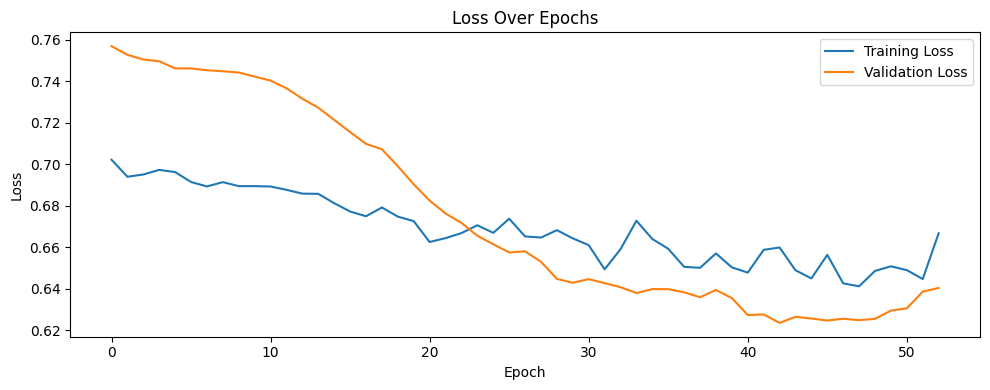

In [91]:
# Import required libraries for Neural Network using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import StandardScaler

# Define a simple neural network for meta-modeling
class StackingNN(nn.Module):
    def __init__(self, input_dim):
        super(StackingNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Convert inputs to numpy arrays if they aren't already
stacked_train = np.column_stack(model_train)
stacked_test = np.column_stack(model_pred)

# Standardize the inputs
scaler = StandardScaler()
stacked_train_scaled = scaler.fit_transform(stacked_train)
stacked_test_scaled = scaler.transform(stacked_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(stacked_train_scaled)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(stacked_test_scaled)

# Create dataset and dataloader for batch training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor.unsqueeze(1))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model, loss function, and optimizer
input_dim = stacked_train.shape[1]
meta_model = StackingNN(input_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(meta_model.parameters(), lr=0.001)

# Training loop
num_epochs = 100
best_loss = float('inf')
patience_counter = 0
patience = 10
best_model_state = None

# Training history
train_losses = []
val_losses = []

# Split data for validation
val_size = int(0.2 * len(X_train_tensor))
train_idx = range(len(X_train_tensor) - val_size)
val_idx = range(len(X_train_tensor) - val_size, len(X_train_tensor))

X_val = X_train_tensor[val_idx]
y_val = y_train_tensor[val_idx].unsqueeze(1)

for epoch in range(num_epochs):
    # Training
    meta_model.train()
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = meta_model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    meta_model.eval()
    with torch.no_grad():
        val_outputs = meta_model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())
        
        # Check for early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model_state = meta_model.state_dict().copy()
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load the best model
if best_model_state:
    meta_model.load_state_dict(best_model_state)

# Generate predictions on test data
meta_model.eval()
with torch.no_grad():
    stacked_pred = meta_model(X_test_tensor).numpy().flatten()

# Compute Brier Score for Neural Network Stacked Model
brier_stacked = brier_score_loss(y_test, stacked_pred)
print(f"🔥 Neural Network Stacked Model -> Brier Score: {brier_stacked:.5f}")

# Optional: Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
# Evaluate individual models
brier_gb = brier_score_loss(y_test, test_pred_gb)
brier_rf = brier_score_loss(y_test, test_pred_rf)
brier_xgb = brier_score_loss(y_test, test_pred_xgb)
brier_lgb = brier_score_loss(y_test, test_pred_lgb)

print(f"\n📊 Individual Model Brier Scores:")
print(f"🚀 Gradient Boosting: {brier_gb:.5f}")
print(f"🌲 Random Forest: {brier_rf:.5f}")
print(f"⚡ XGBoost: {brier_xgb:.5f}")
print(f"🔦 LightGBM: {brier_lgb:.5f}")

# If one model has a very high Brier Score, remove it and re-run stacking



📊 Individual Model Brier Scores:
🚀 Gradient Boosting: 0.20342
🌲 Random Forest: 0.20917
⚡ XGBoost: 0.24780
🔦 LightGBM: 0.22912


🔥 Stacked Model -> Brier Score: 0.21766


# EVAL

In [45]:
import os
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score
import json


In [106]:

models = {
    # "Random Forest": best_rf,
    # "Gradient Boosting": best_gb,
    # "Gradient Boosting DEAP": best_gb_ga,
    "Random forest optuna": best_rf
    
}

results_file = "results.csv"
append_mode = os.path.exists(results_file)

# Open file in append mode
with open(results_file, "a") as f:
    # Write header only if the file does not exist
    if not append_mode:
        f.write("Brier Score,Model,Params,Log Loss,Accuracy\n")
    
    # Evaluate models and save results
    for name, model in models.items():
        y_pred_proba = model.predict_proba(x_test_scaled)[:, 1]
        
        # Get model parameters as a JSON string
        model_params = json.dumps(model.get_params(), indent=None)  # Remove indentation to keep it compact
        
        # Compute Metrics
        brier = brier_score_loss(y_test, y_pred_proba)
        logloss = log_loss(y_test, y_pred_proba)
        accuracy = accuracy_score(y_test, (y_pred_proba > 0.5).astype(int))
        
        print(f"{name} -> Brier Score: {brier:.5f}, Log Loss: {logloss:.5f}, Accuracy: {accuracy:.5f}")
        
        # Append to file
        f.write(f"{brier:.5f},{name},{model_params},{logloss:.5f},{accuracy:.5f}\n")

print(f"Results saved to {results_file}")


Random forest optuna -> Brier Score: 0.21602, Log Loss: 0.62329, Accuracy: 0.67164
Results saved to results.csv


In [107]:
y_pred_proba_gb = best_gb_ga.predict_proba(x_test_scaled)[:, 1]
y_pred_proba_rf = best_rf.predict_proba(x_test_scaled)[:, 1]

ensemble_preds = (y_pred_proba_gb + y_pred_proba_rf) / 2

# Evaluate ensemble
brier_ensemble = brier_score_loss(y_test, ensemble_preds)
print(f"\n🔥 **Ensemble (GB + RF) -> Brier Score: {brier_ensemble:.5f}")


🔥 **Ensemble (GB + RF) -> Brier Score: 0.20714


# simple LR

In [30]:
y_pred_proba = lr_model.predict_proba(x_test_scaled)[:, 1]
y_pred_class = lr_model.predict(x_test_scaled)

# Evaluate model performance
logloss = log_loss(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred_class)
brier_score = brier_score_loss(y_test, y_pred_proba)

print(f"Log Loss: {logloss:.5f}")
print(f"Accuracy: {accuracy:.5f}")
print(f"Brier Score: {brier_score:.5f}")

Log Loss: 0.77622
Accuracy: 0.58209
Brier Score: 0.26449


## 2

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import xgboost as xgb
import pandas as pd
from sklearn.metrics import brier_score_loss

# Define worst features to remove
worst_features = [
    'Feature_40', 'Feature_30', 'Feature_28', 'Feature_19', 'Feature_46',
    # 'Feature_18', 'Feature_20', 'Feature_59', 'Feature_34', 'Feature_38',
    # 'Feature_61', 'Feature_5', 'Feature_60'
]

# Convert x_train and x_test to DataFrame (if not already)
feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
x_train_df = pd.DataFrame(x_train, columns=feature_names).drop(columns=worst_features)
x_test_df = pd.DataFrame(x_test, columns=feature_names).drop(columns=worst_features)

# Standard Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_df)  # Fit on train data
x_test_scaled = scaler.transform(x_test_df)        # Transform test data with same scaler

# Convert back to DataFrame for clarity
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train_df.columns)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x_test_df.columns)

# Define XGBoost parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    # 'use_label_encoder': False
}

# Train the model with best known n_estimators
best_n_estimators = 10  # You can adjust this if needed

final_model = xgb.XGBClassifier(n_estimators=best_n_estimators, **params)
final_model.fit(x_train_scaled_df, y_train)

# Predict probabilities on the test set
y_prob = final_model.predict_proba(x_test_scaled_df)[:, 1]

# Compute new Brier Score
brier_score_final = brier_score_loss(y_test, y_prob)

# Output results
print(f"Final Brier Score after Standard Scaling with n_estimators={best_n_estimators}: {brier_score_final}")


In [ ]:
# Ensure x_train, y_train, x_test, y_test are DataFrames/Numpy arrays
if isinstance(x_train, pd.DataFrame):
    feature_names = x_train.columns
else:
    feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]

# Define initial XGBoost parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'use_label_encoder': False
}

# Train an initial XGBoost model
initial_model = xgb.XGBClassifier(n_estimators=100, **params)
initial_model.fit(x_train, y_train)

# Get feature importance scores
feature_importances = initial_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)  # Sort ascending

# Identify the least important features (bottom 20%)
num_features_to_remove = int(len(feature_importance_df) * 0.2)  # Remove the lowest 20%
worst_features = feature_importance_df.iloc[:num_features_to_remove]['Feature'].tolist()

# Remove the worst features from training and test data
x_train_filtered = pd.DataFrame(x_train, columns=feature_names).drop(columns=worst_features)
x_test_filtered = pd.DataFrame(x_test, columns=feature_names).drop(columns=worst_features)

# Train a new model on the filtered dataset
filtered_model = xgb.XGBClassifier(n_estimators=100, **params)
filtered_model.fit(x_train_filtered, y_train)

# Predict probabilities on the test set
y_prob_filtered = filtered_model.predict_proba(x_test_filtered)[:, 1]

# Compute new Brier Score
brier_score_filtered = brier_score_loss(y_test, y_prob_filtered)

# Output the results
brier_score_filtered, worst_features

In [ ]:
from sklearn.model_selection import RepeatedKFold
worst_features = [
    'Feature_40', 'Feature_30', 'Feature_28', 'Feature_19', 'Feature_46',
    'Feature_18', 'Feature_20', 'Feature_59', 'Feature_34', 'Feature_38',
    'Feature_61', 'Feature_5', 'Feature_60'
]

# Convert to DataFrame and remove worst features
feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
x_train_df = pd.DataFrame(x_train, columns=feature_names).drop(columns=worst_features)
x_test_df = pd.DataFrame(x_test, columns=feature_names).drop(columns=worst_features)

# Convert data to DMatrix format
dtrain = xgb.DMatrix(x_train_df, label=y_train)

# Define XGBoost parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss'
}

# Cross-validation to find the best number of estimators
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=100,
    folds=RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
    early_stopping_rounds=20,
    metrics="logloss",
    as_pandas=True
)

# Get best number of boosting rounds
best_n_estimators = cv_results.shape[0]
print(f"Best number of estimators: {best_n_estimators}")

# Train final model using best number of estimators
final_model = xgb.XGBClassifier(n_estimators=10, **params)
final_model.fit(x_train_df, y_train)

# Predict probabilities on the test set
y_prob = final_model.predict_proba(x_test_df)[:, 1]

# Compute new Brier Score
brier_score_final = brier_score_loss(y_test, y_prob)
print(f"Final Brier Score: {brier_score_final}")

In [ ]:
feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
x_train_df = pd.DataFrame(x_train, columns=feature_names)
x_test_df = pd.DataFrame(x_test, columns=feature_names)

# Remove the worst features
x_train_filtered = x_train_df.drop(columns=worst_features)
x_test_filtered = x_test_df.drop(columns=worst_features)

# Define XGBoost parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'use_label_encoder': False
}

# Train the new model on the filtered dataset
for i in range(100):

    filtered_model = xgb.XGBClassifier(n_estimators=i, **params)
    filtered_model.fit(x_train_filtered, y_train)

    # Predict probabilities on the test set
    y_prob_filtered = filtered_model.predict_proba(x_test_filtered)[:, 1]

    # Compute new Brier Score
    brier_score_filtered = brier_score_loss(y_test, y_prob_filtered)
    print(f"Having {i} estimators. New Brier Score: {brier_score_filtered}")

## 1

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RepeatedKFold, train_test_split
from sklearn.metrics import brier_score_loss

In [ ]:
params = {
    'objective': 'binary:logistic',  # For binary classification
    'eval_metric': 'logloss',  # Log loss is commonly used for binary classification
    'use_label_encoder': False
}

# Cross-validation with RepeatedKFold
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

In [ ]:
dtrain = xgb.DMatrix(x_train, label=y_train)

# Perform cross-validation
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=100,
    folds=cv,
    early_stopping_rounds=10,
    metrics="logloss",
    as_pandas=True
)
best_num_rounds = cv_results.shape[0]
final_model = xgb.XGBClassifier(n_estimators=best_num_rounds, **params)
final_model.fit(x_train, y_train)

In [ ]:
y_prob = final_model.predict_proba(x_test)[:, 1]  # Get probabilities for class 1
# Compute Brier Score
brier_score = brier_score_loss(y_test, y_prob)

# Output the Brier Score
print(f"Brier Score: {brier_score}")

# other 

In [ ]:
# Get x, y train and test fromd data frames
x_train, y_train = x_y_from_data_frame_differences(df_train)
x_test, y_test = x_y_from_data_frame_differences(df_test)

# Get data frames with columns present in x_train and x_test
df_train_x = df_train.iloc[:, 6:]
df_test_x = df_test.iloc[:, 6:]

# Clear NaN if it's present
x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())

In [ ]:
df_train.to_csv("train.csv")
df_test.to_csv("test.csv")

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Calibrate using sigmoid (Platt scaling) with 5-fold CV
calibrated_rf = CalibratedClassifierCV(rf_model, cv=5, method='sigmoid')
calibrated_rf.fit(x_train, y_train)
rf_probs = calibrated_rf.predict_proba(x_test)[:, 1]
rf_brier = brier_score_loss(y_test, rf_probs)
print(f"Calibrated Random Forest Brier Score: {rf_brier:.4f}")

Let's see why it's so poor

In [ ]:
y_pred = calibrated_rf.predict(x_test)  # Get class predictions (0 or 1)
y_pred_proba = calibrated_rf.predict_proba(x_test)[:, 1]  # Get probability predictions

# Step 2: Find the indices of incorrect predictions
incorrect_indices = np.where(y_pred != y_test)[0]

# Step 3: Create a DataFrame to inspect incorrect predictions
# Assuming df_test_x is the pandas DataFrame version of x_test with column names
incorrect_predictions = pd.DataFrame({
    'True_Value': y_test[incorrect_indices],
    'Predicted_Value': y_pred[incorrect_indices],
    'Predicted_Probability': y_pred_proba[incorrect_indices]
})

# Step 4: Merge with the original feature data for analysis
# Get the corresponding rows from the original test DataFrame
if 'df_test_x' in locals() or 'df_test_x' in globals():
    # Add feature values for incorrect predictions
    feature_data = df_test_x.iloc[incorrect_indices].reset_index(drop=True)
    
    # Combine with prediction information
    incorrect_analysis = pd.concat([incorrect_predictions, feature_data], axis=1)
    
    # Sort by probability to see the most confident incorrect predictions first
    incorrect_analysis = incorrect_analysis.sort_values(by='Predicted_Probability', ascending=False)
    
    print(f"Total test samples: {len(y_test)}")
    print(f"Total incorrect predictions: {len(incorrect_indices)}")
    print(f"Error rate: {len(incorrect_indices) / len(y_test):.4f}")
    
    # Display the most confident incorrect predictions
    print("\nMost confident incorrect predictions:")
    print(incorrect_analysis.head(10))
    
    # Find feature importance and correlation with errors
    if hasattr(calibrated_rf, 'estimators_'):
        # For calibrated classifier, access the base estimator's feature importances
        feature_importance = np.mean([estimator.feature_importances_ 
                                     for estimator in calibrated_rf.estimators_], axis=0)
        
        # Create a DataFrame of feature importances
        if df_test_x is not None:
            importance_df = pd.DataFrame({
                'Feature': df_test_x.columns,
                'Importance': feature_importance
            }).sort_values(by='Importance', ascending=False)
            
            print("\nFeature Importance:")
            print(importance_df.head(10))
            
            # Check which features have the largest differences in incorrect predictions
            correct_indices = np.where(y_pred == y_test)[0]
            
            # Calculate mean values for each feature for correct vs incorrect predictions
            feature_analysis = pd.DataFrame()
            for col in df_test_x.columns:
                feature_analysis.loc['Incorrect_Mean', col] = df_test_x.iloc[incorrect_indices][col].mean()
                feature_analysis.loc['Correct_Mean', col] = df_test_x.iloc[correct_indices][col].mean()
                feature_analysis.loc['Difference', col] = abs(feature_analysis.loc['Incorrect_Mean', col] - 
                                                             feature_analysis.loc['Correct_Mean', col])
            
            # Find features with the largest differences
            largest_diff_features = feature_analysis.loc['Difference'].sort_values(ascending=False)
            
            print("\nFeatures with largest differences between correct and incorrect predictions:")
            print(largest_diff_features.head(10))
else:
    print("Original feature DataFrame 'df_test_x' not available.")
    print("Consider mapping x_test back to feature names for better analysis.")

# Basic models

In [ ]:
# Train a GPU-accelerated XGBoost regressor to predict the point difference
xgb_reg = xgb.XGBRegressor(
    tree_method='gpu_hist',  # Use GPU acceleration
    gpu_id=0,                # Specify which GPU to use
    n_estimators=100,
    random_state=42
)
xgb_reg.fit(x_train, y_train)

# Predict the raw point difference
y_pred_raw = xgb_reg.predict(x_test)
mse = mean_squared_error(y_test, y_pred_raw)
print(f"XGBoost Regressor MSE: {mse:.4f}")

# Define a function to post-process predictions:
# If the predicted point difference is greater than 'threshold', predict 1 (win)
# If it's less than -'threshold', predict 0 (loss)
# Otherwise, predict 0.5 (close/tie game)
def post_process(pred, threshold=3):
    if pred > threshold:
        return 1
    elif pred < -threshold:
        return 0
    else:
        return 0.5

# Apply the post-processing function to all predictions (vectorized for efficiency)
post_process_vectorized = np.vectorize(post_process)
y_pred_processed = post_process_vectorized(y_pred_raw)

# Assuming that the true outcomes are also coded as 0, 0.5, or 1,
# we can compute the Brier score for the post-processed predictions.
brier = brier_score_loss(y_test, y_pred_processed)
print(f"Post-processed Predictions Brier Score: {brier:.4f}")


In [ ]:
# --- Model Option 2: Random Forest with Calibration ---
# Random Forest probabilities can be overconfident so we wrap it in a calibration step.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Calibrate using sigmoid (Platt scaling) with 5-fold CV
calibrated_rf = CalibratedClassifierCV(rf_model, cv=5, method='sigmoid')
calibrated_rf.fit(x_train, y_train)
rf_probs = calibrated_rf.predict_proba(x_test)[:, 1]
rf_brier = brier_score_loss(y_test, rf_probs)
print(f"Calibrated Random Forest Brier Score: {rf_brier:.4f}")




In [ ]:
import xgboost as xgb
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
x_train

In [ ]:
# --- GPU-accelerated XGBoost Model ---
# Here, we specify tree_method='gpu_hist' and set gpu_id=0 (change if you have multiple GPUs)
xgb_gpu = xgb.XGBClassifier(
    tree_method='gpu_hist',
    gpu_id=0,
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_gpu.fit(x_train, y_train)

# Predict probabilities and compute the Brier score
xgb_probs = xgb_gpu.predict_proba(x_test)[:, 1]
xgb_brier = brier_score_loss(y_test, xgb_probs)
print(f"XGBoost (GPU) Brier Score: {xgb_brier:.4f}")

# --- Optional: Calibrated XGBoost Model ---
# XGBoost predictions can sometimes be overconfident.
# We calibrate them using Platt scaling (sigmoid) with 5-fold cross-validation.
calibrated_xgb = CalibratedClassifierCV(xgb_gpu, cv=5, method='sigmoid')
calibrated_xgb.fit(x_train, y_train)

# Get calibrated probability predictions and compute the Brier score
calibrated_probs = calibrated_xgb.predict_proba(x_test)[:, 1]
calibrated_brier = brier_score_loss(y_test, calibrated_probs)
print(f"Calibrated XGBoost (GPU) Brier Score: {calibrated_brier:.4f}")

# --- Model Comparison ---
if calibrated_brier < xgb_brier:
    best_model = calibrated_xgb
    best_score = calibrated_brier
    model_name = "Calibrated XGBoost (GPU)"
else:
    best_model = xgb_gpu
    best_score = xgb_brier
    model_name = "XGBoost (GPU)"

print(f"Best Model: {model_name} with a Brier Score of {best_score:.4f}")

# Using point difference

In [ ]:
df_train.columns

In [ ]:
season_to_train_on = 2023
x_train, y_train = x_y_from_data_frame_score(df_train[df_train['Season'] > season_to_train_on])
x_test, y_test = x_y_from_data_frame_score(df_test[df_test['Season'] > season_to_train_on])

# Get data frames with columns present in x_train and x_test
df_train_x = df_train.iloc[:, 6:]
df_test_x = df_test.iloc[:, 6:]

# Clear NaN if it's present
x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())

In [ ]:
xgb_reg = xgb.XGBRegressor(
    tree_method='gpu_hist',  # Use GPU acceleration
    gpu_id=0,                # Specify which GPU to use
    n_estimators=1000,
    random_state=42
)
xgb_reg.fit(x_train, y_train)
# Predict the raw point difference
y_pred_raw = xgb_reg.predict(x_test)
mse = mean_squared_error(y_test, y_pred_raw)
print(f"XGBoost Regressor MSE: {mse:.4f}")

In [ ]:
y_pred_raw = xgb_reg.predict(x_test)
mse = mean_squared_error(y_test, y_pred_raw)
print(f"XGBoost Regressor MSE: {mse:.4f}")

In [ ]:
def calculate_brier_score(y_true, y_pred):
    """
    Calculate the Brier score.
    
    Parameters:
    y_true (array-like): The actual outcomes
    y_pred (array-like): The predicted probabilities
    
    Returns:
    float: The Brier score
    """
    
    # Convert inputs to numpy arrays if they aren't already
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate the squared differences
    squared_diff = (y_true - y_pred) ** 2
    
    # Calculate the mean of the squared differences (Brier score)
    brier_score = np.mean(squared_diff)
    
    return brier_score

In [ ]:
y_test_binary = np.where(y_test > 0, 1, 0)
def post_process(pred, threshold=3):
    if pred > threshold:
        return 1
    elif pred < -threshold:
        return 0
    else:
        return 0.5

# Apply the post-processing function to all predictions (vectorized for efficiency)
post_process_vectorized = np.vectorize(post_process)
y_pred_processed = post_process_vectorized(y_pred_raw)

for i in range(10):
    thres = i/10
    post_process_vectorized = np.vectorize(post_process)
    y_pred_processed = post_process_vectorized(y_pred_raw, threshold = thres)

    # Assuming that the true outcomes are also coded as 0, 0.5, or 1,
    # we can compute the Brier score for the post-processed predictions.

    brier = calculate_brier_score(y_test_binary, y_pred_processed)
    print(f"Threshold: {thres}. Post-processed Predictions Brier Score: {brier:.4f}")

# Year over year

In [ ]:
# Get x, y train and test fromd data frames
x_train, y_train = x_y_from_data_frame(df_train)
x_test, y_test = x_y_from_data_frame(df_test)

# Get data frames with columns present in x_train and x_test
df_train_x = df_train.iloc[:, 6:]
df_test_x = df_test.iloc[:, 6:]

# Clear NaN if it's present
x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())

In [ ]:
season_to_train_on = 2023
x_train, y_train = x_y_from_data_frame_score(df_train[df_train['Season'] > season_to_train_on])
x_test, y_test = x_y_from_data_frame_score(df_test[df_test['Season'] > season_to_train_on])

# Get data frames with columns present in x_train and x_test
df_train_x = df_train.iloc[:, 6:]
df_test_x = df_test.iloc[:, 6:]

# Clear NaN if it's present
x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())

In [ ]:
df_2022_train = df_train[df_train['Season'] == 2022]
df_2023_train = df_train[df_train['Season'] == 2023]
df_2024_train = df_train[df_train['Season'] == 2024]

df_2022_test = df_test[df_test['Season'] == 2022]
df_2023_test = df_test[df_test['Season'] == 2023]
df_2024_test = df_test[df_test['Season'] == 2024]



X_2022_train, y_2022_train = x_y_from_data_frame_score(df_2022_train)
X_2022_test, y_2022_test   = x_y_from_data_frame_score(df_2022_test)

X_2022_train, y_2022_train = clear_na_from_x_y(X_2022_train, y_2022_train)
X_2022_test,  y_2022_test  = clear_na_from_x_y(X_2022_test,  y_2022_test)

In [ ]:
df_test['Season']

In [ ]:
X_2022_train, y_2022_train = x_y_from_data_frame_score(df_2022_train)
X_2022_test, y_2022_test   = x_y_from_data_frame_score(df_2022_test)

X_2022_train, y_2022_train = clear_na_from_x_y(X_2022_train, y_2022_train)
X_2022_test,  y_2022_test  = clear_na_from_x_y(X_2022_test,  y_2022_test)

X_2023_train, y_2023_train = x_y_from_data_frame_score(df_2023_train)
X_2023_test, y_2023_test   = x_y_from_data_frame_score(df_2023_test)

X_2023_train, y_2023_train = clear_na_from_x_y(X_2023_train, y_2023_train)
X_2023_test,  y_2023_test  = clear_na_from_x_y(X_2023_test,  y_2023_test)

X_2024_train, y_2024_train = x_y_from_data_frame_score(df_2024_train)
X_2024_test, y_2024_test   = x_y_from_data_frame_score(df_2024_test)

X_2024_train, y_2024_train = clear_na_from_x_y(X_2024_train, y_2024_train)
X_2024_test,  y_2024_test  = clear_na_from_x_y(X_2024_test,  y_2024_test)

In [ ]:
X_2024_train, y_2024_train = x_y_from_data_frame_score(df_2024_train)
X_2024_test, y_2024_test   = x_y_from_data_frame_score(df_2024_test)

X_2024_train, y_2024_train = clear_na_from_x_y(X_2024_train, y_2024_train)
X_2024_test,  y_2024_test  = clear_na_from_x_y(X_2024_test,  y_2024_test)

In [ ]:
model_2022 = xgb.XGBRegressor(
    tree_method='gpu_hist',  # use GPU acceleration
    gpu_id=0,
    n_estimators=1000,       # high value to allow early stopping
    learning_rate=0.01,      # low learning rate for gradual improvement
    random_state=42
)

# Train on 2022 data using early stopping on the 2022 test set
model_2022.fit(
    X_2022_train, y_2022_train,
    eval_set=[(X_2022_test, y_2022_test)],
    verbose=True
)

In [ ]:
pred_2022 = model_2022.predict(X_2022_test)
mse_2022 = mean_squared_error(y_2022_test, pred_2022)
print(f"=== 2022 Evaluation after fine-tuning ===\nMSE: {mse_2022:.4f}")

In [ ]:
model_2023 = xgb.XGBRegressor(**model_2022.get_params())
model_2023.fit(
    X_2023_train, y_2023_train,
    eval_set=[(X_2023_test, y_2023_test)],
    verbose=True,
    xgb_model=model_2022.get_booster()  # continue training from 2022 model
)

# Evaluate the fine-tuned model on 2023
pred_2023 = model_2023.predict(X_2023_test)
mse_2023 = mean_squared_error(y_2023_test, pred_2023)
print(f"=== 2023 Evaluation after fine-tuning ===\nMSE: {mse_2023:.4f}")

In [ ]:
y_pred_raw = model_2023.predict(x_test)
y_test_binary = np.where(y_test > 0, 1, 0)
def post_process(pred, threshold=3):
    if pred > threshold:
        return 1
    elif pred < -threshold:
        return 0
    else:
        return 0.5

# Apply the post-processing function to all predictions (vectorized for efficiency)
post_process_vectorized = np.vectorize(post_process)
y_pred_processed = post_process_vectorized(y_pred_raw)

for i in range(10):
    thres = i/10
    post_process_vectorized = np.vectorize(post_process)
    y_pred_processed = post_process_vectorized(y_pred_raw, threshold = thres)

    # Assuming that the true outcomes are also coded as 0, 0.5, or 1,
    # we can compute the Brier score for the post-processed predictions.

    brier = calculate_brier_score(y_test_binary, y_pred_processed)
    print(f"Threshold: {thres}. Post-processed Predictions Brier Score: {brier:.4f}")

## NN

In [ ]:
scaler = StandardScaler()
scaler.fit(X_2022_train)

X_2022_train_scaled = scaler.transform(X_2022_train)
X_2022_test_scaled  = scaler.transform(X_2022_test)
X_2023_train_scaled = scaler.transform(X_2023_train)
X_2023_test_scaled  = scaler.transform(X_2023_test)
X_2024_test_scaled  = scaler.transform(X_2024_test)

# train on before 2023

In [ ]:
# Filter training data: use all data before 2023
df_train_before_2023 = df_train[df_train['Season'] < 2023]

# Filter evaluation data: use data for season 2024
df_test_2024 = df_test[df_test['Season'] == 2024]

# Create a random train/validation split from the training data
train_subset, val_subset = train_test_split(df_train_before_2023, test_size=0.2, random_state=42)


In [ ]:
# df_train_before_2023 = df_train[df_train['Season'] < 2023]
# df_test_2024 = df_test[df_test['Season'] == 2024]

X_train, y_train = x_y_from_data_frame_score(train_subset)
X_val, y_val = x_y_from_data_frame_score(val_subset)
X_test, y_test = x_y_from_data_frame_score(df_test_2024)

X_train, y_train = clear_na_from_x_y(X_train, y_train)
X_val, y_val = clear_na_from_x_y(X_val, y_val)
X_test, y_test = clear_na_from_x_y(X_test, y_test)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
model = MLPRegressor(hidden_layer_sizes=(120, 64, 32, 16),
                     activation='relu',
                     solver='adam',
                     max_iter=500,
                     random_state=42,
                     early_stopping=True,
                     n_iter_no_change=10,
                     verbose=True)

# Train on the training subset (with early stopping on validation set internally).
model.fit(X_train_scaled, y_train)

In [ ]:
val_pred = model.predict(X_val_scaled)
val_mse = mean_squared_error(y_val, val_pred)
print(f"Validation MSE: {val_mse:.4f}")

# Finally, evaluate on the 2024 test set.
test_pred = model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, test_pred)
print(f"2024 Test MSE: {test_mse:.4f}")

In [ ]:
y_test_binary = np.where(test_pred > 0, 1, 0)
def post_process(pred, threshold=3):
    if pred > threshold:
        return 1
    elif pred < -threshold:
        return 0
    else:
        return 0.5

# Apply the post-processing function to all predictions (vectorized for efficiency)
post_process_vectorized = np.vectorize(post_process)
y_pred_processed = post_process_vectorized(y_pred_raw)

for i in range(10):
    thres = i/10
    post_process_vectorized = np.vectorize(post_process)
    y_pred_processed = post_process_vectorized(y_pred_raw, threshold = thres)

    # Assuming that the true outcomes are also coded as 0, 0.5, or 1,
    # we can compute the Brier score for the post-processed predictions.

    brier = calculate_brier_score(y_test_binary, y_pred_processed)
    print(f"Threshold: {thres}. Post-processed Predictions Brier Score: {brier:.4f}")

# TABPFN

In [ ]:
from tabpfn import TabPFNClassifier


## 1

In [ ]:
clf = TabPFNClassifier(device='cuda')

In [ ]:
df_train.columns

In [ ]:
X_2022_train, y_2022_train = x_y_from_data_frame(df_2022_train)
X_2022_test, y_2022_test   = x_y_from_data_frame(df_2022_test)

X_2022_train, y_2022_train = clear_na_from_x_y(X_2022_train, y_2022_train)
X_2022_test,  y_2022_test  = clear_na_from_x_y(X_2022_test,  y_2022_test)

X_2023_train, y_2023_train = x_y_from_data_frame(df_2023_train)
X_2023_test, y_2023_test   = x_y_from_data_frame(df_2023_test)

X_2023_train, y_2023_train = clear_na_from_x_y(X_2023_train, y_2023_train)
X_2023_test,  y_2023_test  = clear_na_from_x_y(X_2023_test,  y_2023_test)

X_2024_train, y_2024_train = x_y_from_data_frame(df_2024_train)
X_2024_test, y_2024_test   = x_y_from_data_frame(df_2024_test)

X_2024_train, y_2024_train = clear_na_from_x_y(X_2024_train, y_2024_train)
X_2024_test,  y_2024_test  = clear_na_from_x_y(X_2024_test,  y_2024_test)

In [ ]:
y_2022_train_binary = np.round(y_2022_train).astype(int)
y_2022_train_binary

In [ ]:
clf.fit(X_2022_train, y_2022_train_binary)

In [ ]:
clf.fit(X_train_scaled, y_train)

In [ ]:
prediction_probabilities = clf.predict_proba(X_test)
print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))

## 2

In [ ]:
df_train.columns

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tabpfn import TabPFNClassifier

# --- 1. Filter Data ---
# Use all training data before 2023 and test data for season 2024.
df_train_before_2023 = df_train[df_train['Season'] < 2023]
df_test_2024 = df_test[df_test['Season'] == 2024]

# Create a random train/validation split from the training data.
train_subset, val_subset = train_test_split(df_train_before_2023, test_size=0.2, random_state=42)

# --- 2. Helper Functions for Data Preparation ---
def x_y_from_data_frame_score(df):
    """
    Extract features (X) and continuous target (y) from a DataFrame.
    Assumes target is 'ScoreDifference' and drops the 'Season' column.
    """
    X = df.drop(columns=['Season', 'ScoreDifference'], errors='ignore')
    y = df['ScoreDifference']
    return X, y

def clear_na_from_x_y(X, y):
    """Remove rows with any NaNs in X or y."""
    mask = ~X.isna().any(axis=1) & ~y.isna()
    return X.loc[mask], y.loc[mask]

# Extract features and continuous targets
X_train, y_train_cont = x_y_from_data_frame_score(train_subset)
X_val, y_val_cont = x_y_from_data_frame_score(val_subset)
X_test, y_test_cont = x_y_from_data_frame_score(df_test_2024)

X_train, y_train_cont = clear_na_from_x_y(X_train, y_train_cont)
X_val, y_val_cont = clear_na_from_x_y(X_val, y_val_cont)
X_test, y_test_cont = clear_na_from_x_y(X_test, y_test_cont)

# --- 3. Bin the Continuous Target into Discrete Classes ---
def bin_point_difference(y, threshold=3):
    """
    Bin continuous point differences into three classes:
      - 0: y < -threshold   (loss)
      - 1: -threshold <= y <= threshold (tie/close game)
      - 2: y > threshold    (win)
    """
    return np.where(y < -threshold, 0, np.where(y > threshold, 2, 1))

# Convert continuous targets to discrete classes for each set.
y_train = bin_point_difference(y_train_cont)
y_val   = bin_point_difference(y_val_cont)
y_test  = bin_point_difference(y_test_cont)

# --- 4. Feature Scaling ---
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# --- 5. Train TabPFNClassifier ---
# Instantiate the classifier (adjust N_ensemble_configurations or seed as needed)
clf = TabPFNClassifier(N_ensemble_configurations=32, seed=42)
clf.fit(X_train_scaled, y_train)

# Optionally, check validation predictions:
val_pred = clf.predict(X_val_scaled)
print("Validation predictions (binned classes):", val_pred)

# --- 6. Evaluate on 2024 Test Data Using a Multiclass Brier Score ---
def one_hot_encode(y, num_classes):
    """One-hot encode an array of integer class labels."""
    y_one_hot = np.zeros((len(y), num_classes))
    for i, label in enumerate(y):
        y_one_hot[i, int(label)] = 1
    return y_one_hot

num_classes = 3
y_test_onehot = one_hot_encode(y_test, num_classes)
test_pred_proba = clf.predict_proba(X_test_scaled)

# Compute multiclass Brier score:
brier_score = np.mean(np.sum((test_pred_proba - y_test_onehot) ** 2, axis=1))
print("2024 Test Brier Score:", brier_score)


## 3

In [ ]:
# Get x, y train and test fromd data frames
x_train, y_train = x_y_from_data_frame(df_train)
x_test, y_test = x_y_from_data_frame(df_test)

# Get data frames with columns present in x_train and x_test
df_train_x = df_train.iloc[:, 6:]
df_test_x = df_test.iloc[:, 6:]

# Clear NaN if it's present
x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())

In [ ]:
from tabpfn import TabPFNClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [ ]:
clf = TabPFNClassifier()

In [ ]:
clf.fit(x_train, y_train)

In [ ]:
# Predict probabilities
prediction_probabilities = clf.predict_proba(x_test)
print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))

In [ ]:
prediction_probabilities[:, 1].shape
y_test.shape

In [ ]:
prediction_probabilities = clf.predict_proba(x_test)
print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))
np.mean((y_test - prediction_probabilities[:, 1]) ** 2)

# 4

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

In [ ]:
class RandomSubspaceTabPFN(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=10, subspace_fraction=0.8, tabpfn_kwargs=None, random_state=42):
        """
        n_estimators: Number of TabPFN models to train.
        subspace_fraction: Fraction of features to use in each subspace.
        tabpfn_kwargs: Additional keyword arguments for TabPFNClassifier.
        random_state: Seed for reproducibility.
        """
        self.n_estimators = n_estimators
        self.subspace_fraction = subspace_fraction
        self.tabpfn_kwargs = tabpfn_kwargs if tabpfn_kwargs is not None else {}
        self.random_state = random_state
        self.estimators_ = []  # to store the trained TabPFN models
        self.feature_indices_ = []  # to store the random feature subsets used

    def fit(self, X, y):
        # Ensure X is a numpy array.
        X = np.array(X)
        n_features = X.shape[1]
        n_sub_features = max(1, int(self.subspace_fraction * n_features))
        
        rng = np.random.RandomState(self.random_state)
        self.estimators_ = []
        self.feature_indices_ = []
        
        for i in range(self.n_estimators):
            # Randomly select indices without replacement
            indices = rng.choice(n_features, n_sub_features, replace=False)
            self.feature_indices_.append(indices)
            X_sub = X[:, indices]
            
            # Create and train a TabPFNClassifier on this feature subset.
            clf = TabPFNClassifier(device='cuda', **self.tabpfn_kwargs)
            clf.fit(X_sub, y)
            self.estimators_.append(clf)
        
        return self

    def predict_proba(self, X):
        X = np.array(X)
        preds = []
        for indices, clf in zip(self.feature_indices_, self.estimators_):
            X_sub = X[:, indices]
            preds.append(clf.predict_proba(X_sub))
        # Average predictions over all estimators.
        avg_preds = np.mean(preds, axis=0)
        return avg_preds

    def predict(self, X):
        avg_preds = self.predict_proba(X)
        # Return the class with the highest average probability.
        return np.argmax(avg_preds, axis=1)

In [ ]:
clf = RandomSubspaceTabPFN(
    n_estimators=10,
    subspace_fraction=0.8,
    # tabpfn_kwargs={'seed': 42},
    random_state=42
)

# Train the ensemble
clf.fit(x_train, y_train)


In [ ]:
prediction_probabilities = clf.predict_proba(x_test)
# print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))
np.mean((y_test - prediction_probabilities[:, 1]) ** 2)

In [ ]:
df_train_before_2023 = df_train[df_train['Season'] < 2023]
df_test_2024 = df_test[df_test['Season'] == 2024]

X_train, y_train = x_y_from_data_frame(df_train_before_2023)
X_test, y_test = x_y_from_data_frame(df_test_2024)

X_train, y_train = clear_na_from_x_y(X_train, y_train)
X_test, y_test = clear_na_from_x_y(X_test, y_test)

In [ ]:
clf = RandomSubspaceTabPFN(
    n_estimators=60,
    subspace_fraction=0.8,
    # tabpfn_kwargs={'seed': 42},
    random_state=42
)

# Train the ensemble
clf.fit(X_train, y_train)

In [ ]:
prediction_probabilities = clf.predict_proba(X_test)


In [ ]:
# print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))
np.mean((y_test - prediction_probabilities[:, 1]) ** 2)